In [ ]:
 #Bibliotecas
!pip install laspy lazrs rasterio scipy matplotlib pillow plyfile pandas numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.3/43.3 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.1/86.1 kB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 626.9/626.9 kB 17.6 MB/s eta 0:00:00


In [ ]:
# Abrindo
import laspy
import numpy as np
import matplotlib.pyplot as plt

from scipy.interpolate import griddata

import rasterio
from rasterio.transform import from_origin
from PIL import Image
import pandas as pd

In [ ]:
# Abrindo LAZ - São joao abrange portugal
import laspy

las = laspy.read("/content/LO-194277-06-2024_v01.laz")

In [ ]:
# Classe 5 = High Vegetation


VEGETATION_CLASS = 5

vegetation = las.classification == VEGETATION_CLASS

x = las.x[vegetation]
y = las.y[vegetation]
z = las.z[vegetation]

print(f"Pontos de vegetação alta: {len(x):,}")

Pontos de vegetação alta: 2,451,969


In [ ]:
import numpy as np

# Estatisticas
print(f"Altitude mínima : {z.min():.2f} m")
print(f"Altitude máxima : {z.max():.2f} m")
print(f"Altitude média  : {np.mean(z):.2f} m")
print(f"Desvio padrão   : {np.std(z):.2f} m")

Altitude mínima : 27.00 m
Altitude máxima : 179.60 m
Altitude média  : 82.93 m
Desvio padrão   : 34.46 m


In [ ]:
# Criar DataFrame

df = pd.DataFrame({
    "X": np.array(x),
    "Y": np.array(y),
    "Z": np.array(z)
})

df.head()

,X,Y,Z
0,-5999.978,-23840.065,75.040
1,-5999.968,-23839.093,76.331
2,-5999.958,-23831.528,76.880
3,-5999.949,-23828.042,76.596
4,-5999.960,-23751.911,92.295


In [ ]:
# Estatistica completa
df.describe()

,X,Y,Z
count,2.451969e+06,2.451969e+06,2.451969e+06
mean,-5.457458e+03,-2.356214e+04,8.293313e+01
std,2.857436e+02,3.080575e+02,3.446019e+01
min,-6.000000e+03,-2.400000e+04,2.699600e+01
25%,-5.688788e+03,-2.383969e+04,5.322100e+01
50%,-5.418499e+03,-2.361958e+04,8.146500e+01
75%,-5.219138e+03,-2.330870e+04,1.093590e+02
max,-5.000001e+03,-2.300000e+04,1.795970e+02


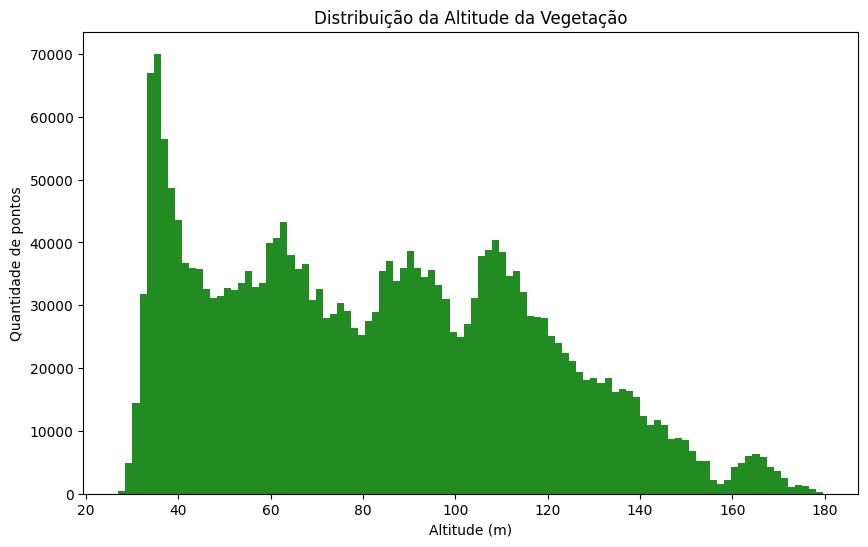

In [ ]:
# Histograma

plt.figure(figsize=(10,6))

plt.hist(
    z,
    bins=100,
    color="forestgreen"
)

plt.xlabel("Altitude (m)")
plt.ylabel("Quantidade de pontos")
plt.title("Distribuição da Altitude da Vegetação")
plt.savefig("histogram.png")
plt.show()

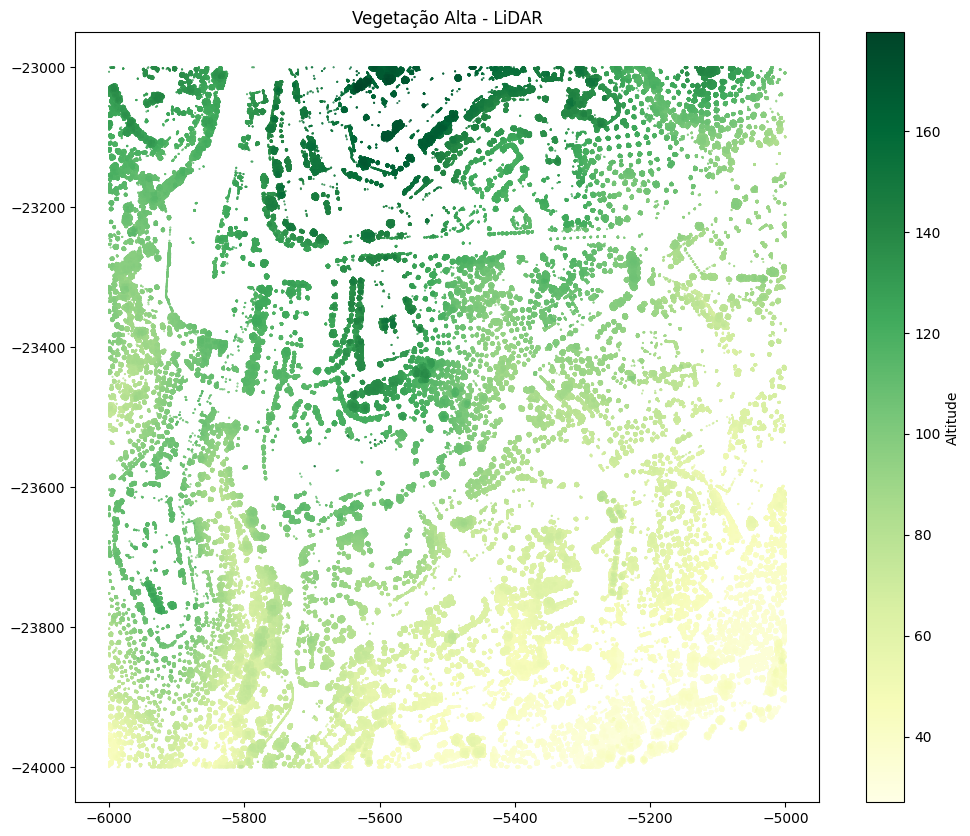

In [ ]:
# Visualização 2D
plt.figure(figsize=(12,10))

plt.scatter(
    x,
    y,
    c=z,
    s=0.2,
    cmap="YlGn"
)

plt.colorbar(label="Altitude")

plt.title("Vegetação Alta - LiDAR")
plt.savefig("2d_vegetacao.png")
plt.show()

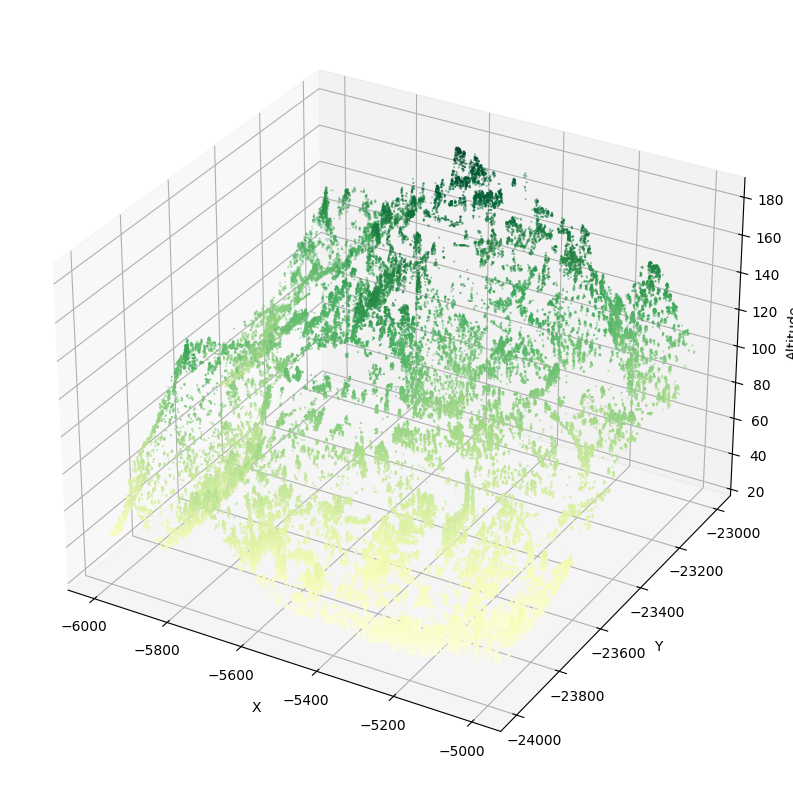

In [ ]:
# Visualização 3D

sample = np.random.choice(
    len(x),
    100000,
    replace=False
)

fig = plt.figure(figsize=(12,10))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    x[sample],
    y[sample],
    z[sample],
    c=z[sample],
    cmap="YlGn",
    s=0.2
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Altitude")
plt.savefig("3d_vegetacao.png")
plt.show()

In [ ]:
# PLY para Blender
from plyfile import PlyData, PlyElement

vertex = np.array(
    list(zip(x, y, z)),
    dtype=[
        ('x', 'f4'),
        ('y', 'f4'),
        ('z', 'f4')
    ]
)

ply = PlyData([
    PlyElement.describe(vertex, 'vertex')
])

ply.write("Vegetacao_Alta.ply")

print("Arquivo salvo.")

Arquivo salvo.


VAMOS GERAR UM CANOPY HEIGHT MODEL (CHM) QUE CALCULA A ALTURA REAL DAS ÁRVORES E NÃO APENAS A ALTITUDE DAS COPAS.

In [ ]:
# Pegando os pontos de solo e vegetação alta

# Ground (Classe 2) - solo


ground = las.classification == 2

x_ground = las.x[ground]
y_ground = las.y[ground]
z_ground = las.z[ground]

print(f"Ground: {len(x_ground):,} pontos")



# High Vegetation (Classe 5) - vegetação alta


veg = las.classification == 5

x_veg = las.x[veg]
y_veg = las.y[veg]
z_veg = las.z[veg]

print(f"Vegetação: {len(x_veg):,} pontos")

Ground: 10,510,590 pontos
Vegetação: 2,451,969 pontos


In [ ]:
# Interpolador de terreno
from scipy.spatial import cKDTree

ground_xy = np.column_stack((x_ground, y_ground))

tree = cKDTree(ground_xy)

print("KDTree criado com sucesso.")

KDTree criado com sucesso.


In [ ]:
# Procura o terreno para cada arvore
veg_xy = np.column_stack((x_veg, y_veg))

distancias, indices = tree.query(
    veg_xy,
    k=1
)

In [ ]:
# altitude do solo
z_ground_interp = z_ground[indices]

# calcula altura da árvore
tree_height = z_veg - z_ground_interp

In [ ]:
# remove valores inválidos
mask = (tree_height > 0) & (tree_height < 80)

tree_height = tree_height[mask]

x_tree = x_veg[mask]
y_tree = y_veg[mask]

In [ ]:
# estatísticas
print(f"Altura mínima : {tree_height.min():.2f} m")

print(f"Altura máxima : {tree_height.max():.2f} m")

print(f"Altura média  : {tree_height.mean():.2f} m")

print(f"Desvio padrão : {tree_height.std():.2f} m")

Altura mínima : 0.00 m
Altura máxima : 37.88 m
Altura média  : 5.51 m
Desvio padrão : 3.43 m


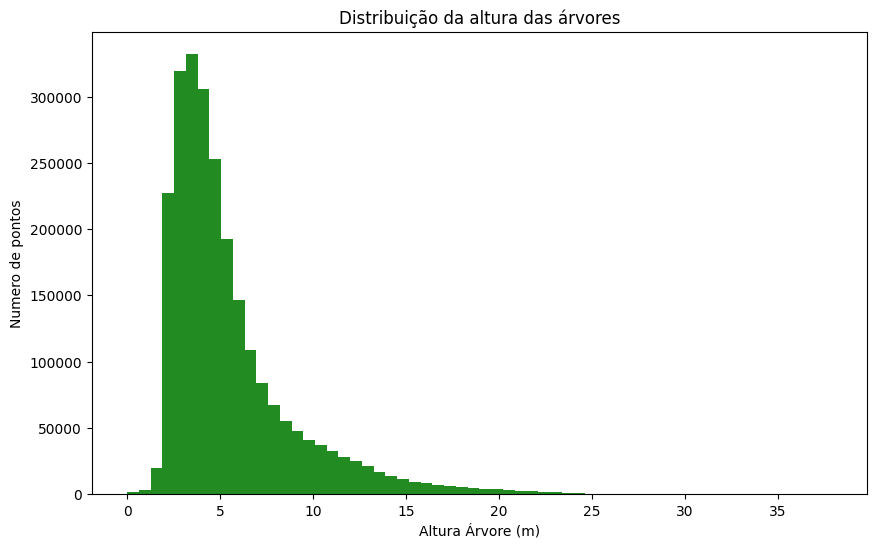

In [ ]:
# histograma
plt.figure(figsize=(10,6))

plt.hist(
    tree_height,
    bins=60,
    color="forestgreen"
)

plt.xlabel("Altura Árvore (m)")
plt.ylabel("Numero de pontos")
plt.title("Distribuição da altura das árvores")
plt.savefig("histogram_arvorealtura.png")
plt.show()

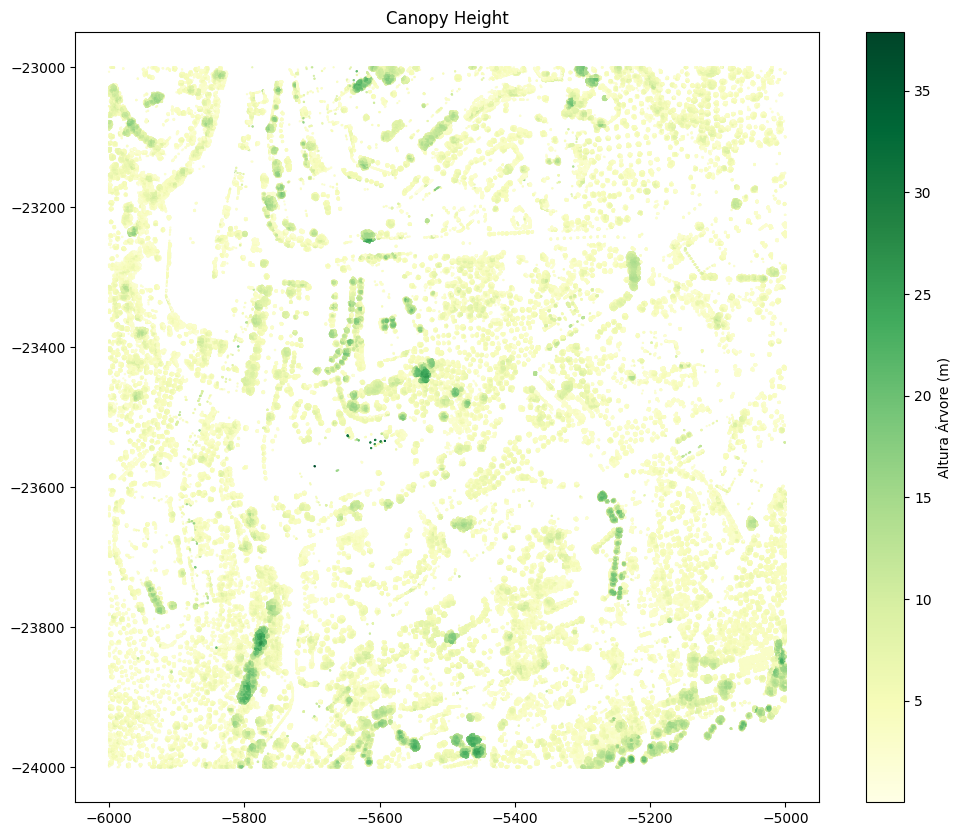

In [ ]:
# mapa das alturas
plt.figure(figsize=(12,10))

plt.scatter(
    x_tree,
    y_tree,
    c=tree_height,
    s=0.3,
    cmap="YlGn"
)

plt.colorbar(label="Altura Árvore (m)")

plt.title("Canopy Height")
plt.savefig("2d_canopyheight.png")
plt.show()

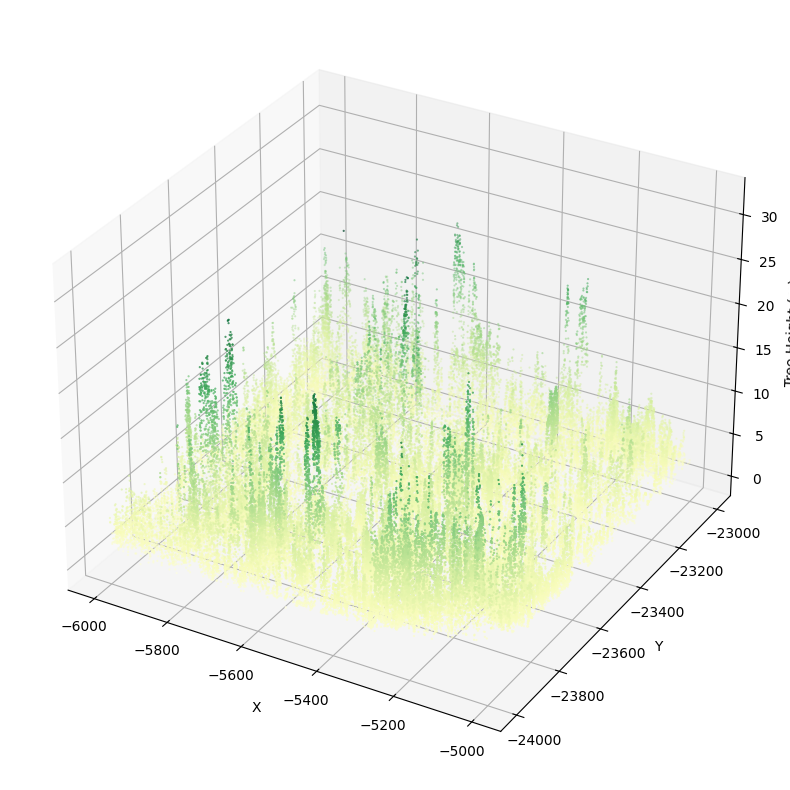

In [ ]:
# 3D
sample = np.random.choice(
    len(tree_height),
    100000,
    replace=False
)

fig = plt.figure(figsize=(12,10))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    x_tree[sample],
    y_tree[sample],
    tree_height[sample],
    c=tree_height[sample],
    cmap="YlGn",
    s=0.3
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Tree Height (m)")
plt.savefig("3d_canopyheight.png")
plt.show()

In [ ]:
# csv

df = pd.DataFrame({
    "X": x_tree,
    "Y": y_tree,
    "Tree_Height": tree_height
})

df.to_csv("Tree_Height.csv", index=False)

print("CSV salvo.")

KeyboardInterrupt: 